In [8]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import matplotlib.pyplot as plt

In [2]:
!pip install pandas_ta

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 3.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=7b9aac773cfdfd63eef8098e70b9045035c88c0cd1fa3d1d6bd0d6fbc3026491
  Stored in directory: /root/.cache/pip/wheels/7f/33/8b/50b245c5c65433cd8f5cb24ac15d97e5a3db2d41a8b6ae957d
Successfully built pandas_ta


In [28]:
data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')
data.head()

,Date,Open,High,Low,Close,Volume
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10


In [29]:
# اضافه کردن ستون سیگنال با مقدار پیش‌فرض 'hold'
data['Signal'] = 'hold'

# تنظیم اندازه پنجره و گام
window_size = 10
step = 10

# پیمایش روی داده‌ها با پنجره متحرک
for start in range(0, len(data) - window_size + 1, step):
    # انتخاب پنجره فعلی
    window = data.iloc[start:start + window_size]
    
    # پیدا کردن اندیس کمترین مقدار Low و بیشترین مقدار High در پنجره
    min_low_idx = window['Close'].idxmin()
    max_high_idx = window['Close'].idxmax()
    
    # تخصیص سیگنال‌ها
    data.loc[min_low_idx, 'Signal'] = 'buy'
    data.loc[max_high_idx, 'Signal'] = 'sell'

In [30]:
data.head(20)

,Date,Open,High,Low,Close,Volume,Signal
0,15.08.2017 00:00:00.000,1.17786,1.17812,1.17750,1.17759,6070.48,hold
1,15.08.2017 01:00:00.000,1.17759,1.17802,1.17752,1.17783,3163.99,hold
2,15.08.2017 02:00:00.000,1.17783,1.17802,1.17682,1.17755,4086.81,hold
3,15.08.2017 03:00:00.000,1.17757,1.17895,1.17751,1.17811,6937.33,hold
4,15.08.2017 04:00:00.000,1.17812,1.17928,1.17812,1.17855,7265.10,sell
5,15.08.2017 05:00:00.000,1.17853,1.17859,1.17815,1.17828,5104.43,hold
6,15.08.2017 06:00:00.000,1.17829,1.17842,1.17799,1.17820,4574.70,hold
7,15.08.2017 07:00:00.000,1.17821,1.17861,1.17768,1.17773,4769.83,hold
8,15.08.2017 08:00:00.000,1.17774,1.17795,1.17600,1.17605,6931.68,hold
9,15.08.2017 09:00:00.000,1.17605,1.17639,1.17358,1.17429,12798.18,buy


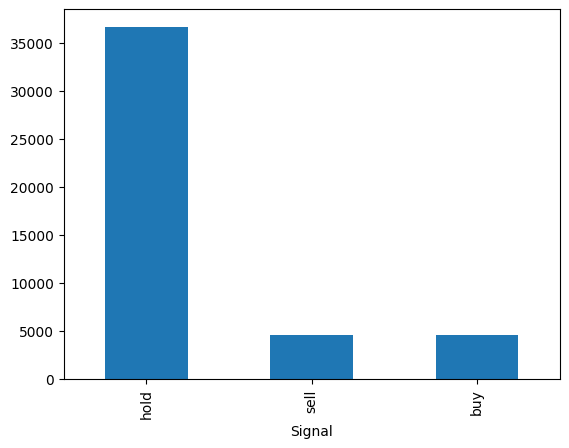

In [31]:
import matplotlib.pyplot as plt
data['Signal'].value_counts(dropna=False).plot(kind='bar')
plt.show()

In [32]:
data['Signal'].value_counts(dropna=False)

Signal
hold    36693
sell     4586
buy      4586
Name: count, dtype: int64

In [33]:
import pandas_ta as ta
data['RSI'] = ta.rsi(data['Close'], length=14)
data['sma10'] = ta.sma(data['Close'], length=10)
data['sma50'] = ta.sma(data['Close'], length=50)
macd = ta.macd(data['Close'], fast=12, slow=26, Signal=9)
data['macd_line'] = macd['MACD_12_26_9']
data['macd_Signal'] = macd['MACDs_12_26_9']
data['macd_diff'] = data['macd_line'] - data['macd_Signal']
data['sma_diff'] = data['sma50'] - data['sma10']


data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)
bb = ta.bbands(data['Close'], length=20, std=2)
data['BB_upper'] = bb['BBU_20_2.0']
data['BB_lower'] = bb['BBL_20_2.0']
data['BB_mid'] = bb['BBM_20_2.0']
data['Close_lag1'] = data['Close'].shift(1)
data['Close_lag2'] = data['Close'].shift(2)
data.dropna(inplace=True)

data.head()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


,Date,Open,High,Low,Close,Volume,Signal,RSI,sma10,sma50,macd_line,macd_Signal,macd_diff,sma_diff,ATR,BB_upper,BB_lower,BB_mid,Close_lag1,Close_lag2
49,17.08.2017 01:00:00.000,1.17712,1.17793,1.17705,1.17776,3865.97,sell,67.299652,1.173869,1.174137,0.000717,-0.000183,0.000900,0.000268,0.001835,1.178487,1.167738,1.173113,1.17713,1.17665
50,17.08.2017 02:00:00.000,1.17772,1.17791,1.17698,1.17737,3134.37,hold,65.033882,1.174659,1.174132,0.000880,0.000030,0.000850,-0.000527,0.001769,1.178963,1.167605,1.173284,1.17776,1.17713
51,17.08.2017 03:00:00.000,1.17737,1.17745,1.17649,1.17679,6088.52,hold,61.706650,1.175311,1.174112,0.000950,0.000214,0.000736,-0.001199,0.001710,1.179282,1.167541,1.173412,1.17737,1.17776
52,17.08.2017 04:00:00.000,1.17679,1.17888,1.17669,1.17885,9345.45,sell,67.973832,1.176179,1.174138,0.001159,0.000403,0.000756,-0.002041,0.001745,1.179970,1.167315,1.173643,1.17679,1.17737
53,17.08.2017 05:00:00.000,1.17885,1.17899,1.17775,1.17824,7011.27,hold,64.602175,1.176989,1.174140,0.001261,0.000575,0.000686,-0.002849,0.001708,1.180530,1.167275,1.173903,1.17885,1.17679


In [50]:
import pandas as pd
import pandas_ta as ta

# فرض می‌کنیم داده‌ها لود شده‌اند
# data = pd.read_csv('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

# ویژگی‌های پیشنهادی
# 1. فاصله از کمترین/بیشترین
data['Min_Low_Window'] = data['Low'].rolling(window=10).min().shift(1)
data['Max_High_Window'] = data['High'].rolling(window=10).max().shift(1)
data['Dist_to_Min_Low'] = (data['Low'] - data['Min_Low_Window']) / data['Min_Low_Window']
data['Dist_to_Max_High'] = (data['High'] - data['Max_High_Window']) / data['Max_High_Window']

# 2. موقعیت نسبی قیمت
data['Window_Range'] = data['High'].rolling(window=10).max() - data['Low'].rolling(window=10).min()
data['Price_Position'] = (data['Close'] - data['Low'].rolling(window=10).min()) / data['Window_Range']

# 3. تعداد کندل‌های صعودی/نزولی
data['Bullish_Candles'] = (data['Close'] > data['Open']).rolling(window=10).sum()
data['Bearish_Candles'] = (data['Close'] < data['Open']).rolling(window=10).sum()

# 4. انحراف از میانگین
data['Window_Mean'] = data['Close'].rolling(window=10).mean()
data['Price_Deviation'] = (data['Close'] - data['Window_Mean']) / data['Window_Mean']

# 5. نوسانات
data['Window_Volatility'] = (data['High'].rolling(window=10).max() - data['Low'].rolling(window=10).min()) / data['Close'].rolling(window=10).mean()

# 6. الگوهای کندل‌استیک
data['Doji'] = ta.cdl_doji(data['Open'], data['High'], data['Low'], data['Close'])

# 7. شتاب قیمت
data['Price_Velocity'] = data['Close'].diff()
data['Price_Acceleration'] = data['Price_Velocity'].diff()

# حذف مقادیر NaN
data.dropna(inplace=True)

# نمایش داده‌ها
data[['Signal', 'Dist_to_Min_Low', 'Price_Position', 'Bullish_Candles', 'Price_Deviation']].head()

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)


,Signal,Dist_to_Min_Low,Price_Position,Bullish_Candles,Price_Deviation
59,1,-0.001779,0.053422,2.0,-0.003131
60,0,-0.002234,0.031359,2.0,-0.004831
61,0,-0.001153,0.072289,2.0,-0.005001
62,0,-0.002404,0.291308,2.0,-0.004084
63,1,0.001672,0.246468,2.0,-0.003825


In [34]:
data['Signal'] = data['Signal'].map({'buy': 1, 'sell': -1, 'hold': 0})

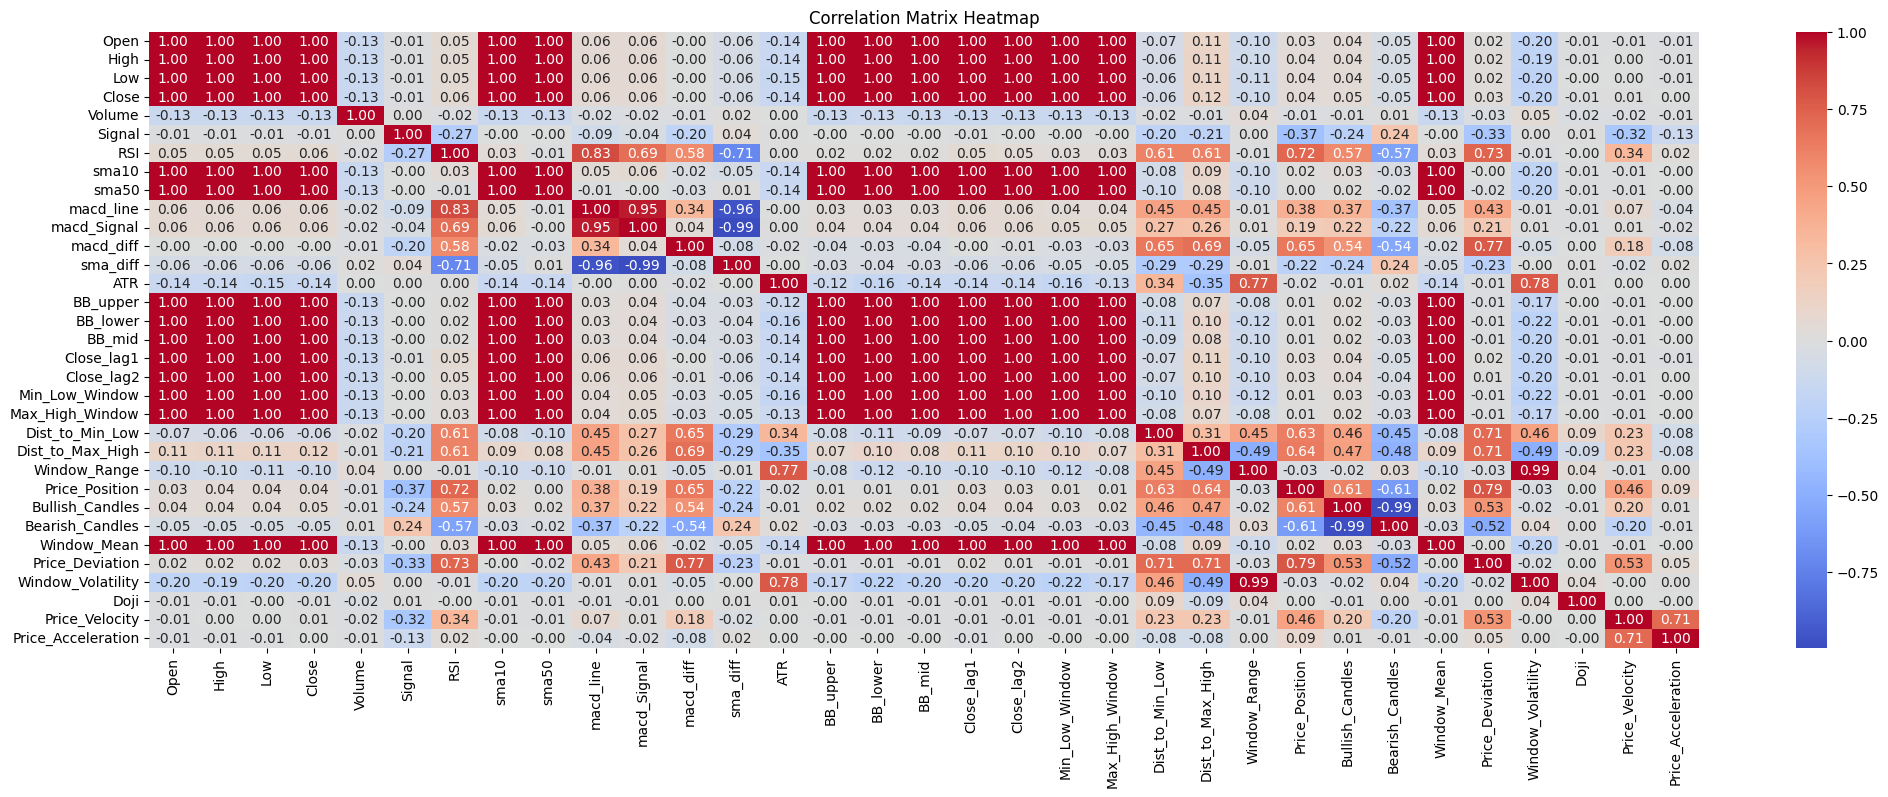

In [51]:
import seaborn as sns

correlation_matrix = data.drop(['Date'],axis=1).corr()
plt.figure(figsize=(25, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

In [52]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Signal', 'RSI',
       'sma10', 'sma50', 'macd_line', 'macd_Signal', 'macd_diff', 'sma_diff',
       'ATR', 'BB_upper', 'BB_lower', 'BB_mid', 'Close_lag1', 'Close_lag2',
       'Min_Low_Window', 'Max_High_Window', 'Dist_to_Min_Low',
       'Dist_to_Max_High', 'Window_Range', 'Price_Position', 'Bullish_Candles',
       'Bearish_Candles', 'Window_Mean', 'Price_Deviation',
       'Window_Volatility', 'Doji', 'Price_Velocity', 'Price_Acceleration'],
      dtype='object')

In [53]:
features = ['Close', 'Volume', 'RSI',
       'sma10', 'sma50', 'macd_line', 'macd_Signal', 'macd_diff', 'sma_diff',
       'ATR', 'BB_upper', 'BB_lower', 'BB_mid', 'Close_lag1', 'Close_lag2',
       'Min_Low_Window', 'Max_High_Window', 'Dist_to_Min_Low',
       'Dist_to_Max_High', 'Window_Range', 'Price_Position', 'Bullish_Candles',
       'Bearish_Candles', 'Window_Mean', 'Price_Deviation',
       'Window_Volatility', 'Doji', 'Price_Velocity', 'Price_Acceleration']
# features = ['RSI', 'sma10', 'sma50']
X = data[features]
y = data['Signal']

# تقسیم داده‌ها به مجموعه آموزش و تست (80% آموزش، 20% تست)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,shuffle=False)

In [54]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

In [55]:
y_pred = dt_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Accuracy: 0.6565

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.22      0.27      0.24       916
    Hold (0)       0.82      0.75      0.78      7330
     Buy (1)       0.22      0.31      0.26       916

    accuracy                           0.66      9162
   macro avg       0.42      0.44      0.43      9162
weighted avg       0.70      0.66      0.68      9162



In [56]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
               Feature  Importance
24     Price_Deviation    0.103427
27      Price_Velocity    0.095600
18    Dist_to_Max_High    0.092712
1               Volume    0.068042
20      Price_Position    0.063561
28  Price_Acceleration    0.062937
17     Dist_to_Min_Low    0.059144
7            macd_diff    0.052106
9                  ATR    0.050346
2                  RSI    0.041647
25   Window_Volatility    0.034367
19        Window_Range    0.031497
5            macd_line    0.030336
6          macd_Signal    0.028334
8             sma_diff    0.026326
4                sma50    0.019195
10            BB_upper    0.016204
11            BB_lower    0.016015
21     Bullish_Candles    0.013052
16     Max_High_Window    0.012590
12              BB_mid    0.011824
15      Min_Low_Window    0.011795
0                Close    0.010725
22     Bearish_Candles    0.010717
23         Window_Mean    0.009861
14          Close_lag2    0.009074
3                sma10    0.009049

In [ ]:
features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_Signal', 'sma_diff', 'macd_diff']

X = data[features]
y = data['Signal']

In [57]:
y_mapped = y.map({-1: 0, 0: 1, 1: 2})  # -1 -> 0 (Sell), 0 -> 1 (Hold), 1 -> 2 (Buy)

# تقسیم داده‌ها به مجموعه آموزش و تست
X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

In [58]:
import xgboost as xgb
xgb_model = xgb.XGBClassifier(objective='multi:softmax', num_class=3, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None, num_class=3,
              num_parallel_tree=None, ...)

In [59]:
y_pred = xgb_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Sell (-1)', 'Hold (0)', 'Buy (1)']))

Accuracy: 0.7921

Classification Report:
              precision    recall  f1-score   support

   Sell (-1)       0.39      0.06      0.11       959
    Hold (0)       0.81      0.97      0.88      7340
     Buy (1)       0.33      0.07      0.11       863

    accuracy                           0.79      9162
   macro avg       0.51      0.37      0.37      9162
weighted avg       0.72      0.79      0.73      9162



In [43]:
# نمایش اهمیت ویژگی‌ها
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)
print("\nFeature Importance:")
print(feature_importance)


Feature Importance:
        Feature  Importance
2           RSI    0.178539
5     macd_line    0.127997
6   macd_Signal    0.061493
8      sma_diff    0.061368
9           ATR    0.060442
7     macd_diff    0.058338
12       BB_mid    0.056024
1        Volume    0.052421
14   Close_lag2    0.051498
4         sma50    0.051061
0         Close    0.049825
10     BB_upper    0.049775
11     BB_lower    0.048723
13   Close_lag1    0.048305
3         sma10    0.044191


XGBoost tree visualization saved as 'xgboost_tree3.png'


<Figure size 5000x1000 with 0 Axes>

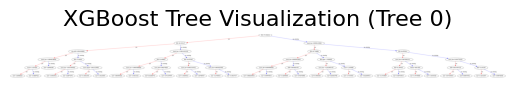

In [45]:
plt.figure(figsize=(50, 10))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='TB')  # افزایش اندازه فونت
plt.title('XGBoost Tree Visualization (Tree 0)', fontsize=16)
plt.savefig('xgboost_tree0.png', dpi=1500, bbox_inches='tight')  # افزایش DPI و تنظیم حاشیه
print("XGBoost tree visualization saved as 'xgboost_tree3.png'")

XGBoost tree visualization saved as 'xgboost_tree3.png'


<Figure size 5000x1000 with 0 Axes>

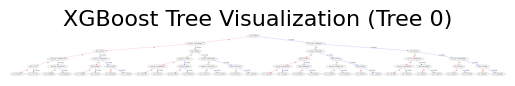

In [46]:
plt.figure(figsize=(50, 10))
xgb.plot_tree(xgb_model, num_trees=2, rankdir='TB')  # افزایش اندازه فونت
plt.title('XGBoost Tree Visualization (Tree 0)', fontsize=16)
plt.savefig('xgboost_tree2.png', dpi=1500, bbox_inches='tight')  # افزایش DPI و تنظیم حاشیه
print("XGBoost tree visualization saved as 'xgboost_tree3.png'")

In [22]:
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.metrics import accuracy_score, classification_report
# import xgboost as xgb
# from tqdm import tqdm

# # تعریف ویژگی‌ها و داده‌ها
# features = ['Close', 'RSI', 'sma10', 'sma50', 'macd_line', 'macd_Signal', 'ema_diff', 'macd_diff']
# X = data[features]
# y = data['Signal']

# # تبدیل برچسب‌ها به مقادیر غیرمنفی (0, 1, 2) برای XGBoost
# y_mapped = y.map({-1: 0, 0: 1, 1: 2})  # -1 -> 0 (Sell), 0 -> 1 (Hold), 1 -> 2 (Buy)

# # تقسیم داده‌ها به مجموعه آموزش و تست
# X_train, X_test, y_train, y_test = train_test_split(X, y_mapped, test_size=0.2, random_state=42)

# # تعریف مدل پایه XGBoost با پشتیبانی از GPU
# xgb_model = xgb.XGBClassifier(
#     objective='multi:softmax',
#     num_class=3,
#     random_state=42,
#     device='cuda'  # استفاده از GPU (برای نسخه‌های قدیمی‌تر از tree_method='gpu_hist' استفاده کن)
# )

# # تعریف شبکه پارامترها برای جستجو
# param_grid = {
#     'max_depth': [3, 5, 7],
#     'learning_rate': [0.01, 0.1, 0.3],
#     'n_estimators': [50, 100, 200],
#     'subsample': [0.6, 0.8, 1.0],
#     'colsample_bytree': [0.6, 0.8, 1.0]
# }

# # تنظیم GridSearchCV
# grid_search = GridSearchCV(
#     estimator=xgb_model,
#     param_grid=param_grid,
#     scoring='accuracy',  # معیار بهینه‌سازی: دقت
#     cv=5,  # تعداد فولدهای اعتبارسنجی متقاطع
#     verbose=0,  # خاموش کردن verbose پیش‌فرض
#     n_jobs=-1  # استفاده از تمام هسته‌های CPU برای سرعت بیشتر
# )

# # محاسبه تعداد کل ترکیب‌ها
# n_combinations = 1
# for key in param_grid:
#     n_combinations *= len(param_grid[key])
# n_combinations *= 5  # ضرب در تعداد فولدها (cv=5)

# # اجرای GridSearchCV با نوار پیشرفت tqdm
# with tqdm(total=n_combinations, desc="GridSearchCV Progress") as pbar:
#     def callback(*args, **kwargs):
#         pbar.update(1)
#     # تابع fit رو با callback اجرا می‌کنیم
#     grid_search.fit(X_train, y_train)
#     pbar.update(n_combinations - pbar.n)  # مطمئن می‌شیم که نوار به 100% برسه

# # نمایش بهترین پارامترها و دقت
# print("Best Parameters:", grid_search.best_params_)
# print("Best Accuracy (on validation set):", grid_search.best_score_)

# # استفاده از بهترین مدل برای پیش‌بینی
# best_model = grid_search.best_estimator_
# y_pred = best_model.predict(X_test)

# # ارزیابی مدل روی داده‌های تست
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Accuracy on Test Set: {accuracy:.4f}")
# print("\nClassification Report on Test Set:")
# print(classification_report(y_test, y_pred, target_names=['Sell (0)', 'Hold (1)', 'Buy (2)']))

In [ ]:
import pickle
with open('best_xgboost_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
print("Model saved as 'best_xgboost_model.pkl' using pickle")

In [47]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import matplotlib.pyplot as plt

def test_model_and_plot(csv_path):
    # خواندن دیتاست از فایل CSV
    data = pd.read_csv(csv_path)

    # بررسی مقادیر نامعتبر در ستون Close
    if not data['Close'].replace([np.inf, -np.inf], np.nan).notnull().all():
        print("Warning: Invalid values (inf or NaN) found in 'Close' column. Replacing with NaN...")
        data['Close'].replace([np.inf, -np.inf], np.nan, inplace=True)

    data['RSI'] = ta.rsi(data['Close'], length=14)
    data['sma10'] = ta.sma(data['Close'], length=10)
    data['sma50'] = ta.sma(data['Close'], length=50)
    macd = ta.macd(data['Close'], fast=12, slow=26, Signal=9)
    data['macd_line'] = macd['MACD_12_26_9']
    data['macd_Signal'] = macd['MACDs_12_26_9']
    data['macd_diff'] = data['macd_line'] - data['macd_Signal']
    data['sma_diff'] = data['sma50'] - data['sma10']
    
    
    data['ATR'] = ta.atr(data['High'], data['Low'], data['Close'], length=14)
    bb = ta.bbands(data['Close'], length=20, std=2)
    data['BB_upper'] = bb['BBU_20_2.0']
    data['BB_lower'] = bb['BBL_20_2.0']
    data['BB_mid'] = bb['BBM_20_2.0']
    data['Close_lag1'] = data['Close'].shift(1)
    data['Close_lag2'] = data['Close'].shift(2)
    data.dropna(inplace=True)

    features = ['Close', 'Volume', 'RSI',
       'sma10', 'sma50', 'macd_line', 'macd_Signal', 'macd_diff', 'sma_diff',
       'ATR', 'BB_upper', 'BB_lower', 'BB_mid', 'Close_lag1', 'Close_lag2']
    
    X = data[features]

    # پیش‌بینی سیگنال‌ها
    data['predicted_Signal'] = xgb_model.predict(X)

    # انتخاب 5 دسته 100تایی متوالی به صورت رندوم
    max_start = len(data) - 100
    random_starts = np.random.choice(range(max_start), size=5, replace=False)

    # رسم 5 نمودار
    for i, start in enumerate(random_starts):
        end = start + 100
        subset = data.iloc[start:end]

        # ایجاد زیرنمودارها (3 ردیف: قیمت، RSI، MACD)
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8), sharex=True, 
                                             gridspec_kw={'height_ratios': [2, 1, 1], 'hspace': 0.05})

        # نمودار قیمت و EMA
        ax1.plot(subset.index, subset['Close'], label='Close Price', color='black')
        ax1.plot(subset.index, subset['sma10'], label='sma10', color='blue')
        ax1.plot(subset.index, subset['sma50'], label='sma50', color='orange')

        # رسم سیگنال‌ها با مثلث
        buy_Signals = subset[subset['predicted_Signal'] == 2]  # Buy
        sell_Signals = subset[subset['predicted_Signal'] == 0]  # Sell

        ax1.scatter(buy_Signals.index, buy_Signals['Close'], marker='^', color='green', label='Buy', s=100)
        ax1.scatter(sell_Signals.index, sell_Signals['Close'], marker='v', color='red', label='Sell', s=100)

        ax1.set_title(f'Close Price, EMA, RSI, MACD, and Predicted Signals (Sample {i+1})')
        ax1.set_ylabel('Price')
        ax1.legend()
        ax1.grid(True)

        # نمودار RSI
        ax2.plot(subset.index, subset['RSI'], label='RSI', color='purple')
        ax2.axhline(y=70, color='red', linestyle='--')
        ax2.axhline(y=30, color='green', linestyle='--')
        ax2.set_ylabel('RSI')
        ax2.legend()
        ax2.grid(True)

        # نمودار MACD
        ax3.plot(subset.index, subset['macd_line'], label='MACD Line', color='blue')
        ax3.plot(subset.index, subset['macd_Signal'], label='MACD Signal', color='orange')
        ax3.set_xlabel('Index')
        ax3.set_ylabel('MACD')
        ax3.legend()
        ax3.grid(True)

        plt.show()


    print("Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.")

/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in less
  return op(a, b)
/usr/local/lib/python3.11/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


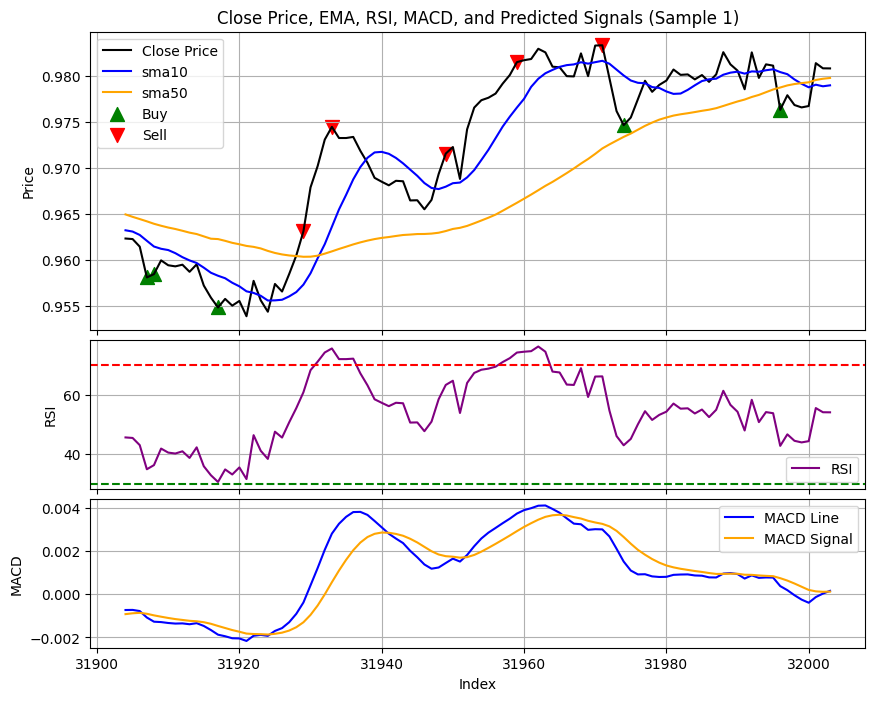

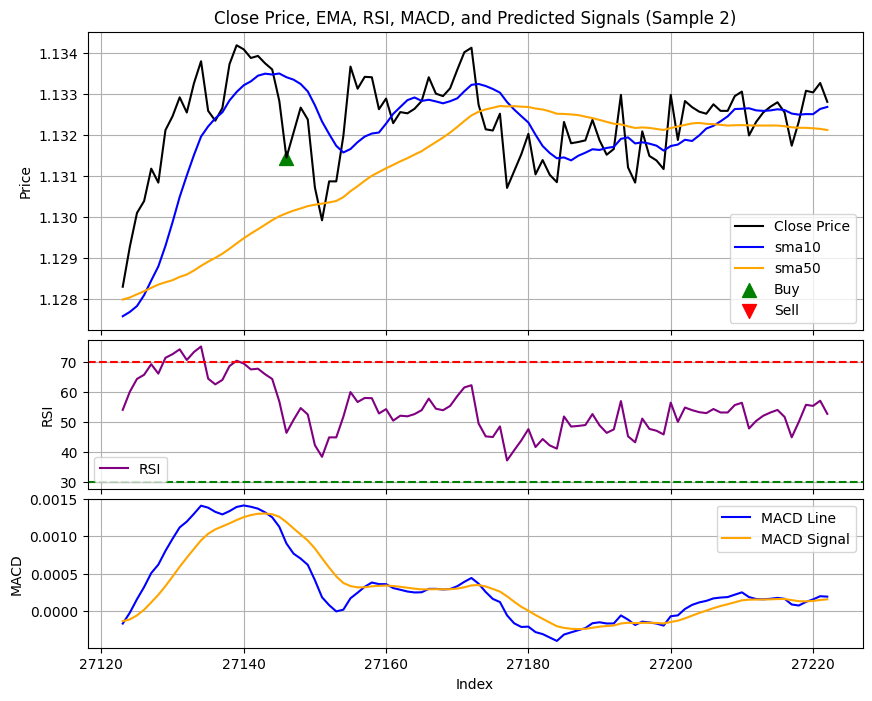

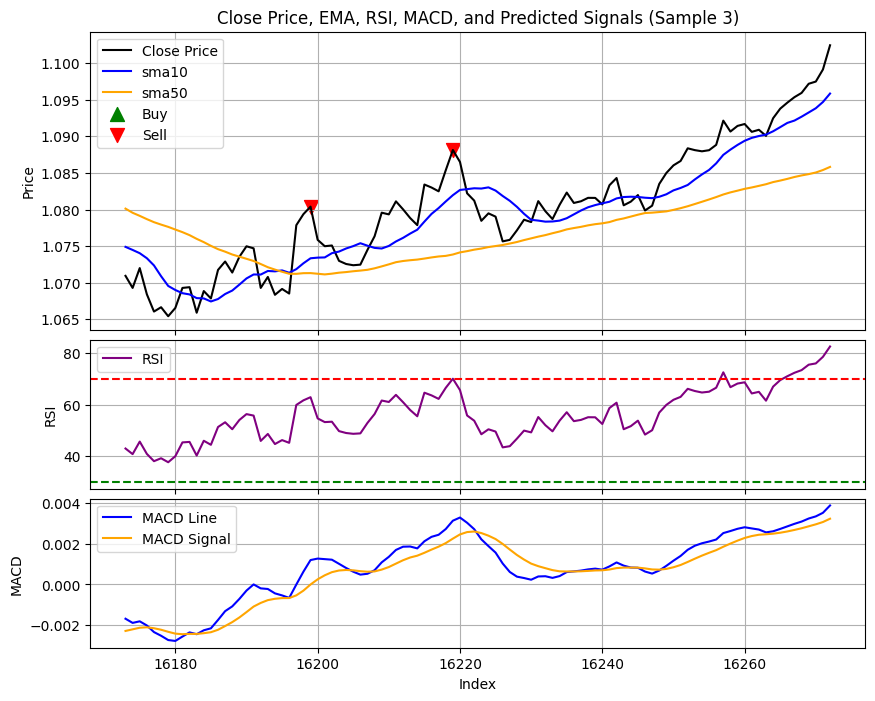

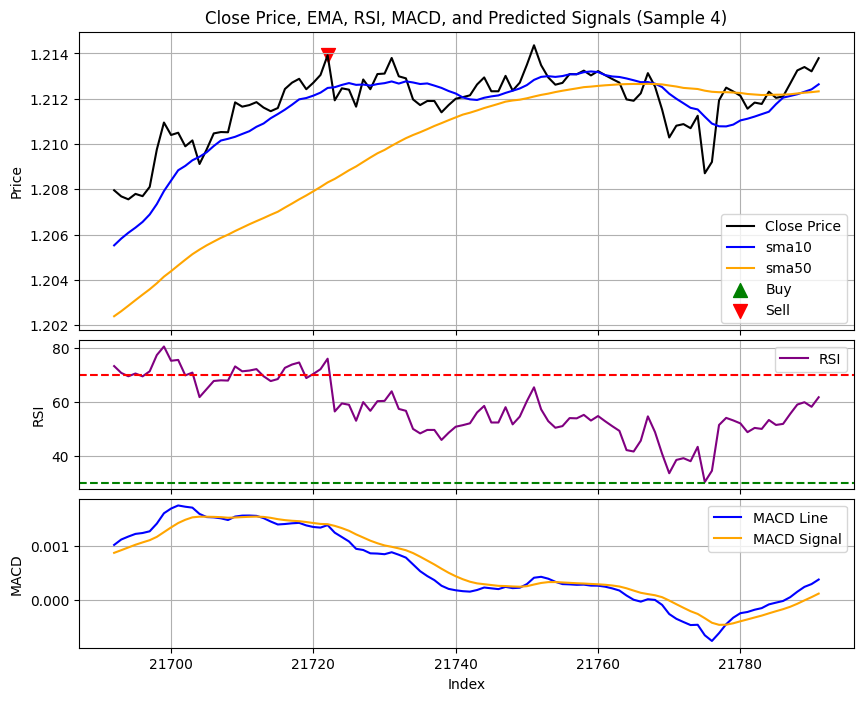

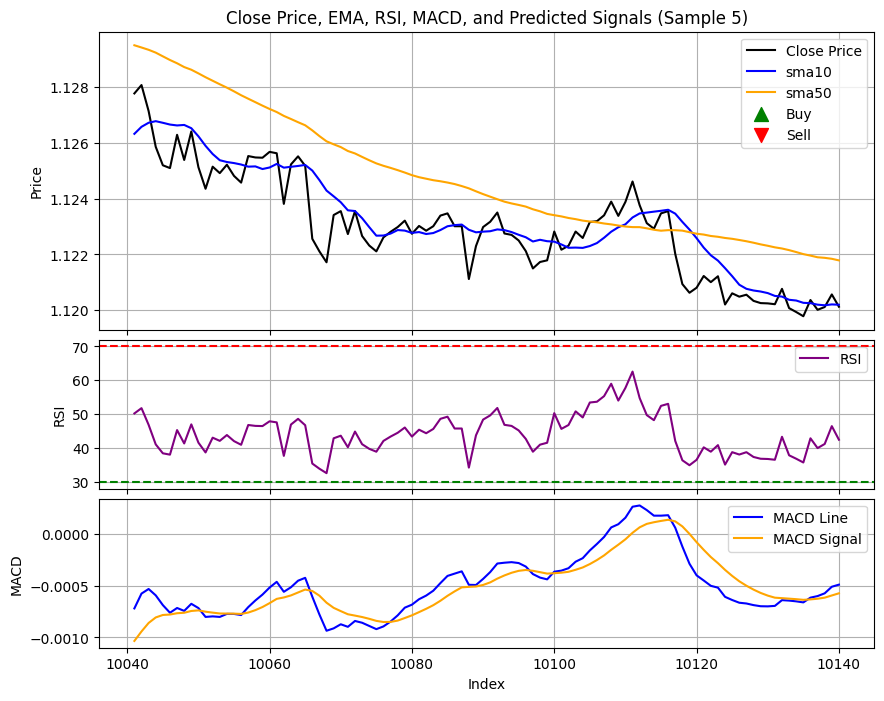

Plots saved as 'Signal_plot_1.png' to 'Signal_plot_5.png'. You can download them from Kaggle output.


In [48]:
test_model_and_plot('/kaggle/input/eurusd60/EURUSD-60-DS-redate.csv')

XGBoost tree visualization saved as 'xgboost_tree3.png'


<Figure size 5000x1000 with 0 Axes>

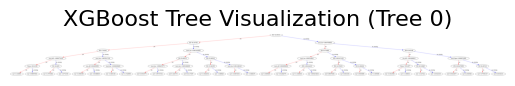

In [27]:
plt.figure(figsize=(50, 10))
xgb.plot_tree(xgb_model, num_trees=0, rankdir='TB')  # افزایش اندازه فونت
plt.title('XGBoost Tree Visualization (Tree 0)', fontsize=16)
plt.savefig('xgboost_tree3.png', dpi=1500, bbox_inches='tight')  # افزایش DPI و تنظیم حاشیه
print("XGBoost tree visualization saved as 'xgboost_tree3.png'")